In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('stores_new.csv')
df.head()

,StoreCode,StoreName,StoreType,Location,OperatingCost,StaffCnt,TotalSales,TotalCustomers,AcqCostPercust,BasketSize,ProfitPercust,OwnStore,OnlinePresence,Tenure,StoreSegment,Discounted Sales,TotalCost
0,STR101,Electronics Zone,Electronincs,Delhi,21.0,60,160.0,110,3.90,2.620,16.46,0,1,4,4,152.0,450.00
1,STR102,Apparel Zone,Apparel,Delhi,21.0,60,160.0,110,3.90,2.875,17.02,0,1,4,4,152.0,450.00
2,STR103,Super Bazar,Super Market,Delhi,22.8,40,108.0,93,3.85,2.320,18.61,1,1,4,1,102.6,380.85
3,STR104,Super Market,Super Market,Delhi,21.4,60,258.0,110,3.08,3.215,19.44,1,0,3,1,245.1,360.20
4,STR105,Central Store,Super Market,Delhi,18.7,80,360.0,175,3.15,3.440,17.02,0,0,3,2,342.0,569.95


### Bivariate Analysis

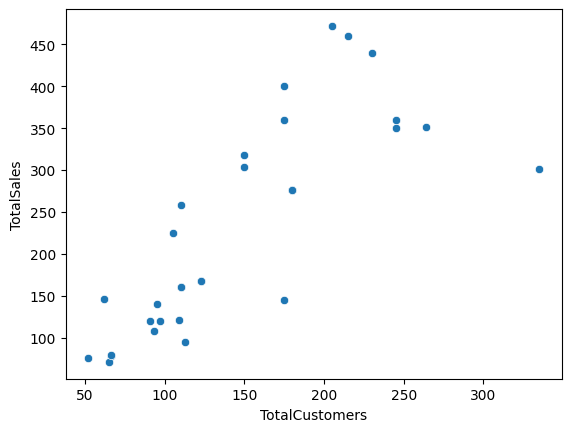

In [ ]:
# Continuous + Continuous
# Scatter plots provides the directionality of relationship but misses out on quantification part.
sns.scatterplot(data = df, x = 'TotalCustomers', y = 'TotalSales')
plt.show()

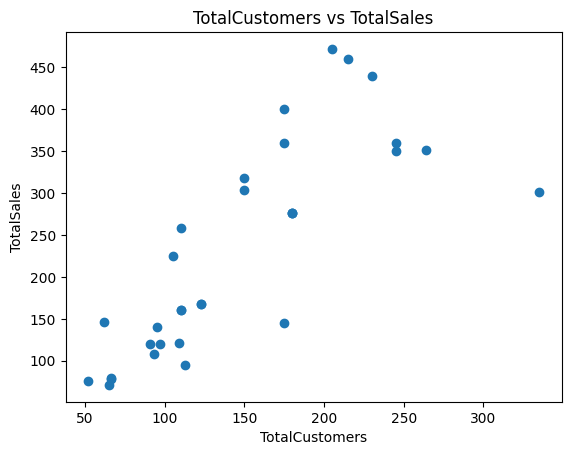

In [6]:
plt.title('TotalCustomers vs TotalSales')
plt.scatter(x = df.TotalCustomers, y = df.TotalSales)
plt.xlabel('TotalCustomers')
plt.ylabel('TotalSales')
plt.show()

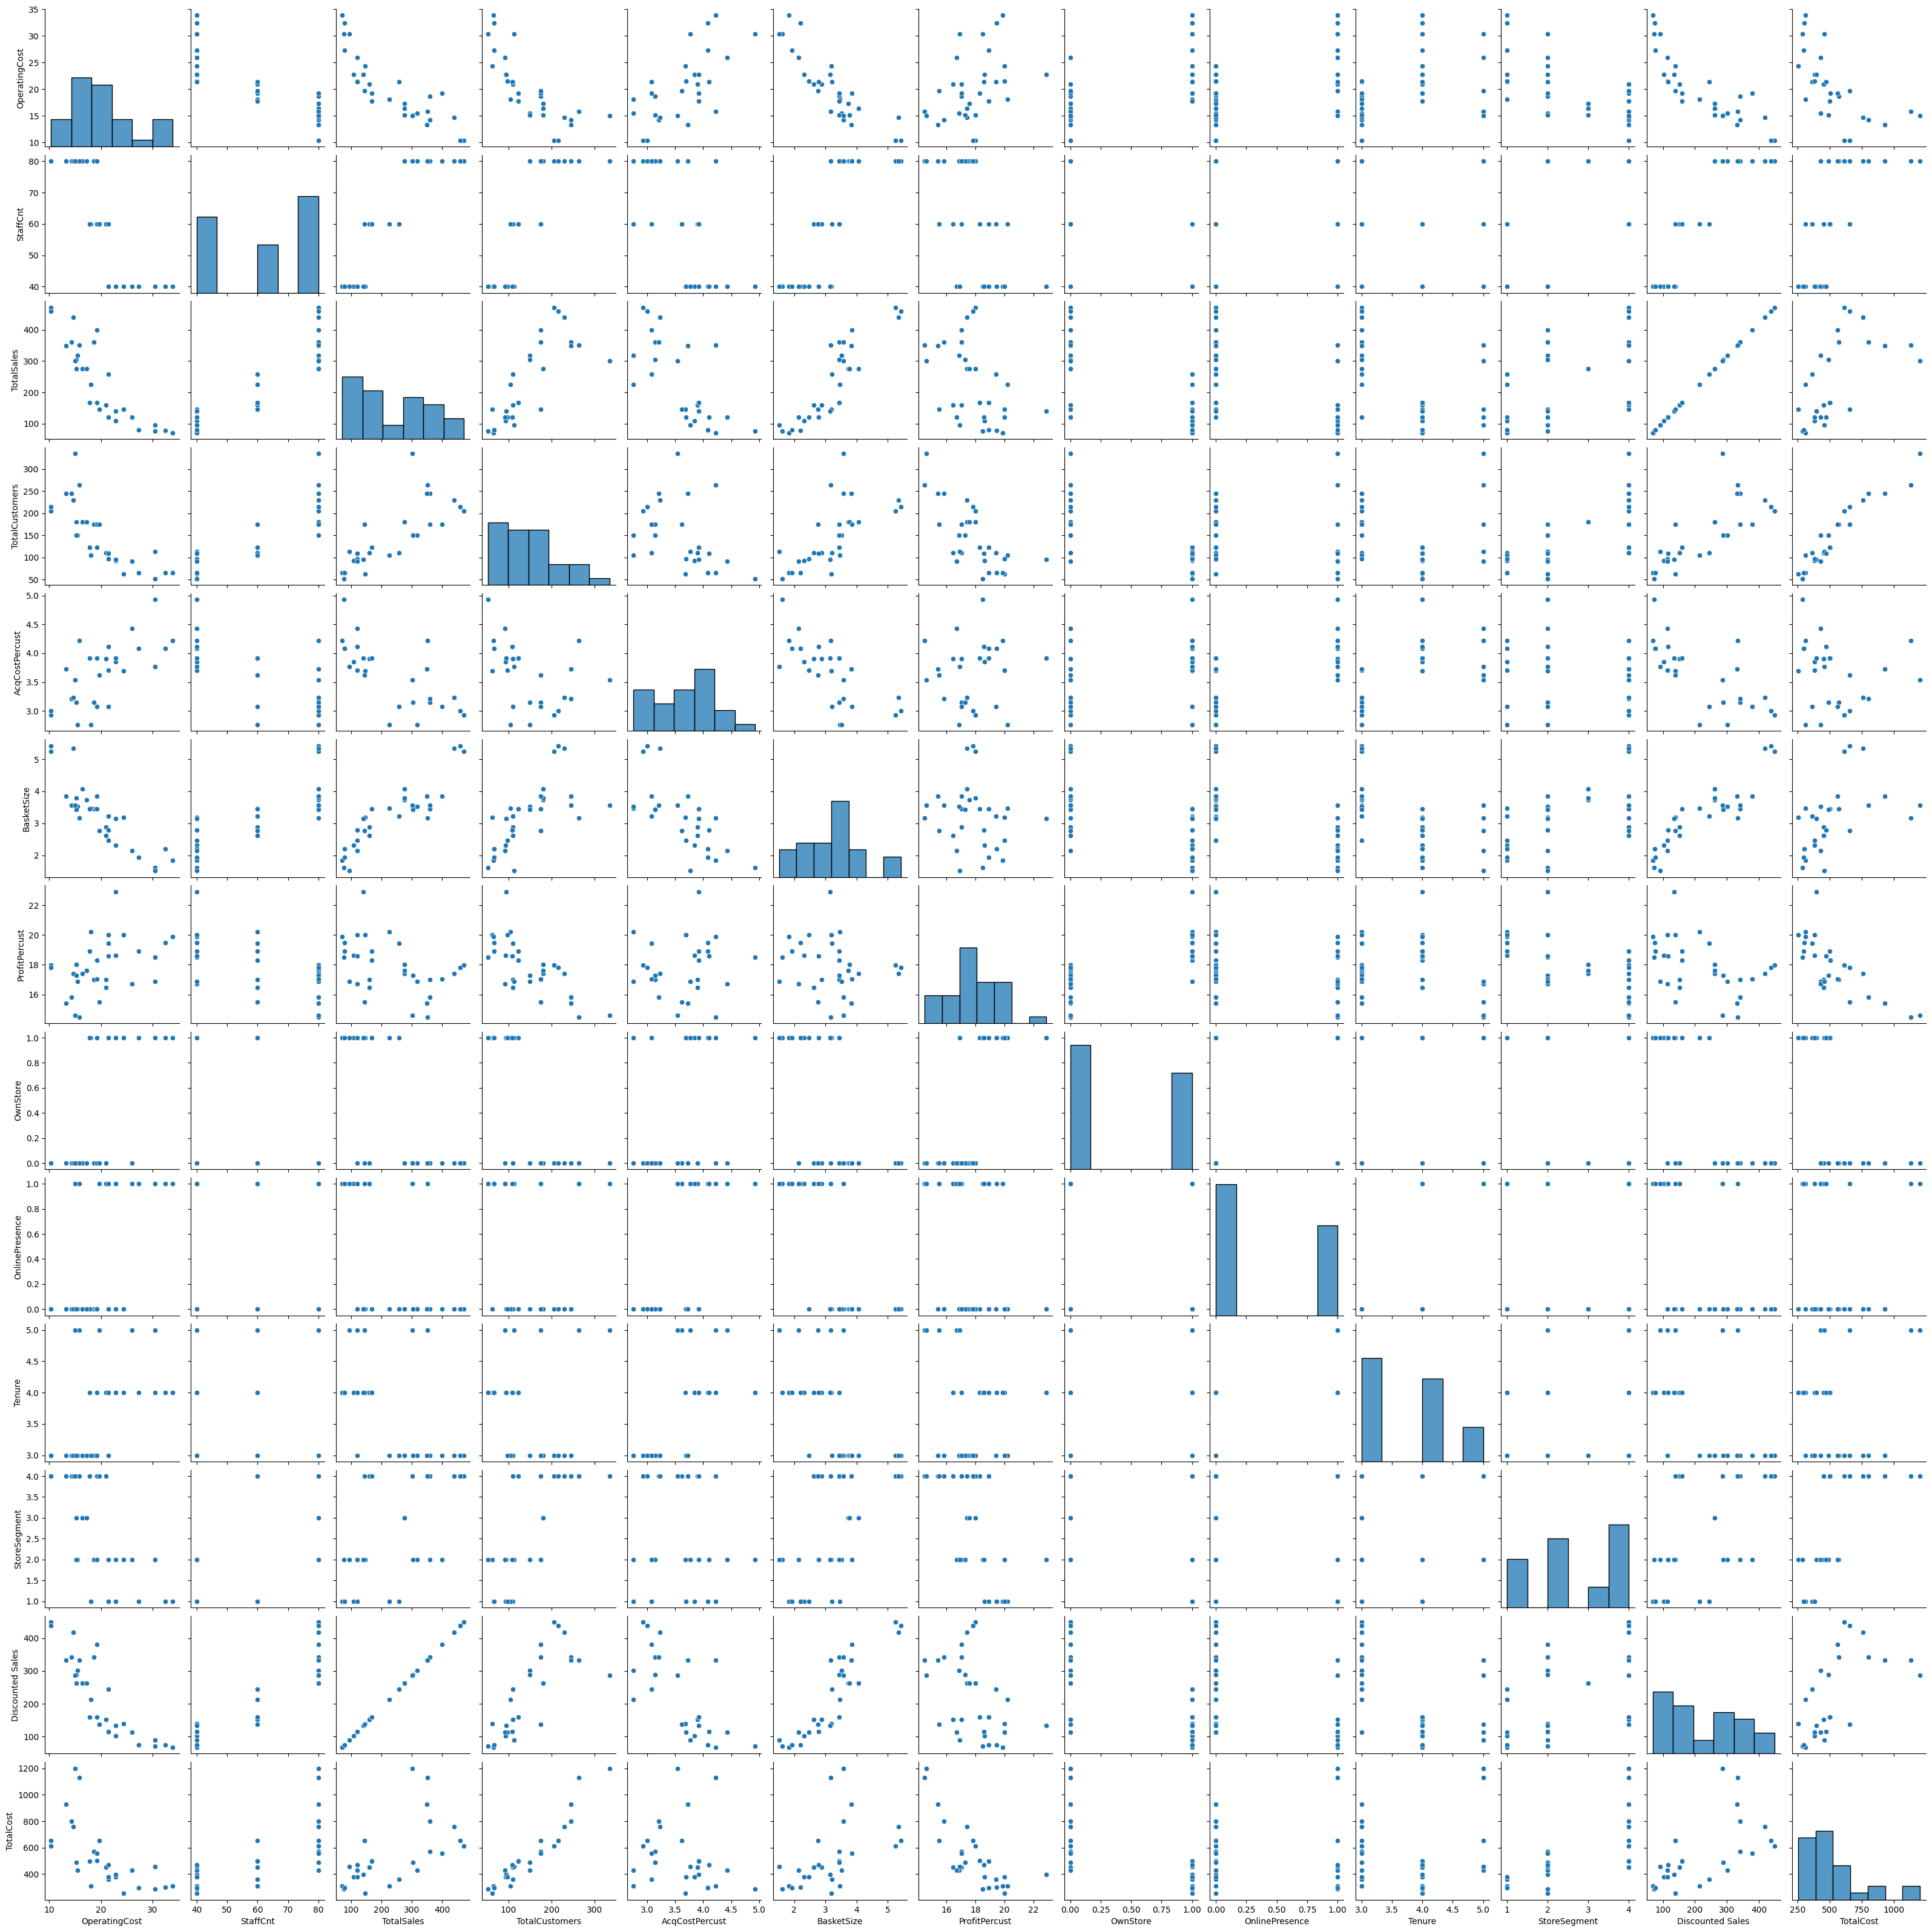

In [7]:
# pairplot
sns.pairplot(df)

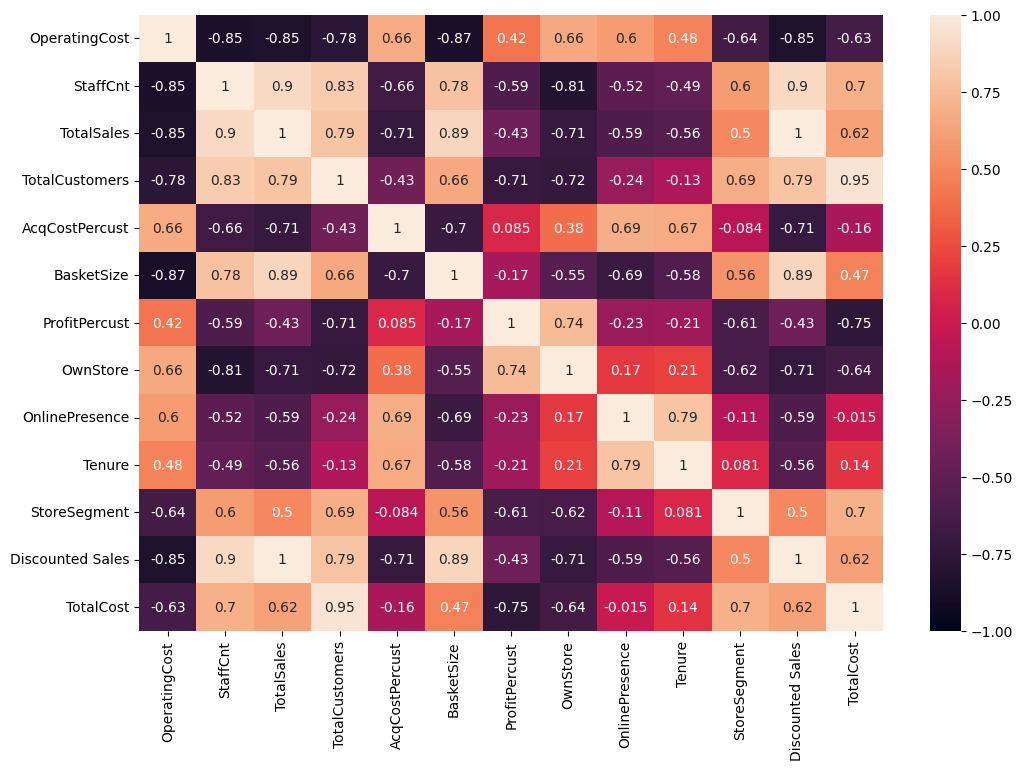

In [15]:
# Correlation - quantify the relationship between 2 numerical variables.
# Correlations as capped within -1 to 1
# Correlations are unitless.

"""
-1 to 0 -> Negative correation => 2 variables are invesely proportional
~0 => Weak correlation
0 to 1 => Positive correlation => 2 variables are directly proportional
"""
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(exclude='object').corr(), annot=True, vmin = -1, vmax = 1)
plt.show()

In [16]:
# Categorical + Categorical
df.head()

,StoreCode,StoreName,StoreType,Location,OperatingCost,StaffCnt,TotalSales,TotalCustomers,AcqCostPercust,BasketSize,ProfitPercust,OwnStore,OnlinePresence,Tenure,StoreSegment,Discounted Sales,TotalCost
0,STR101,Electronics Zone,Electronincs,Delhi,21.0,60,160.0,110,3.90,2.620,16.46,0,1,4,4,152.0,450.00
1,STR102,Apparel Zone,Apparel,Delhi,21.0,60,160.0,110,3.90,2.875,17.02,0,1,4,4,152.0,450.00
2,STR103,Super Bazar,Super Market,Delhi,22.8,40,108.0,93,3.85,2.320,18.61,1,1,4,1,102.6,380.85
3,STR104,Super Market,Super Market,Delhi,21.4,60,258.0,110,3.08,3.215,19.44,1,0,3,1,245.1,360.20
4,STR105,Central Store,Super Market,Delhi,18.7,80,360.0,175,3.15,3.440,17.02,0,0,3,2,342.0,569.95


<Axes: xlabel='StoreName', ylabel='Location'>

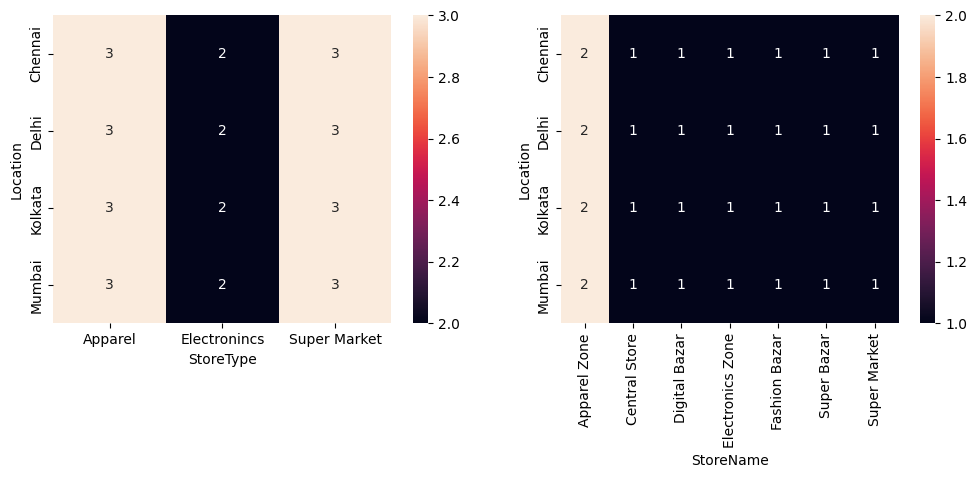

In [ ]:
# Build 2 heatmaps side by side defining the relationship of Location vs StoreType and Location vs StoreName.
_, ax = plt.subplots(nrows=1, ncols=2, figsize =(12,4))
sns.heatmap(pd.crosstab(index = df.Location, columns=df.StoreType), annot=True, ax = ax[0]) # annot will provide the numerical values on top of given cells
sns.heatmap(pd.crosstab(index = df.Location, columns=df.StoreName), annot=True, ax = ax[1])

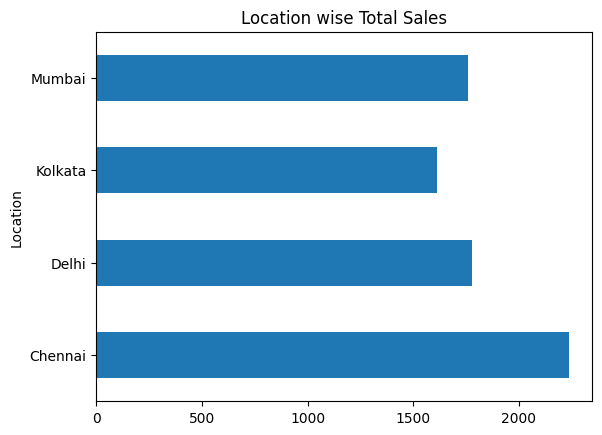

In [31]:
# Categorical + Continuous

# Build bar chart for Total Sales per location

df.groupby('Location').TotalSales.sum().plot(kind = 'barh')
plt.title('Location wise Total Sales')
plt.show()

<Axes: ylabel='TotalSales'>

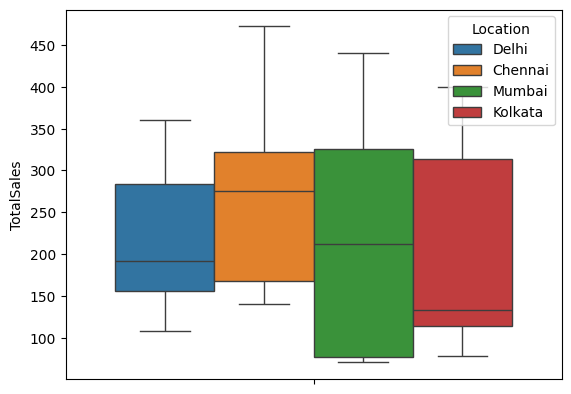

In [ ]:
# Overall distribution of Sales per location
sns.boxplot(data = df, y = 'TotalSales', hue='Location')

<Axes: xlabel='TotalSales', ylabel='Count'>

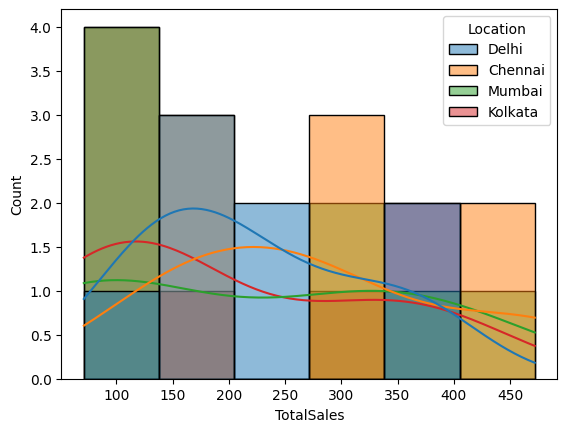

In [38]:
sns.histplot(data = df, x = 'TotalSales', kde=True, hue='Location')

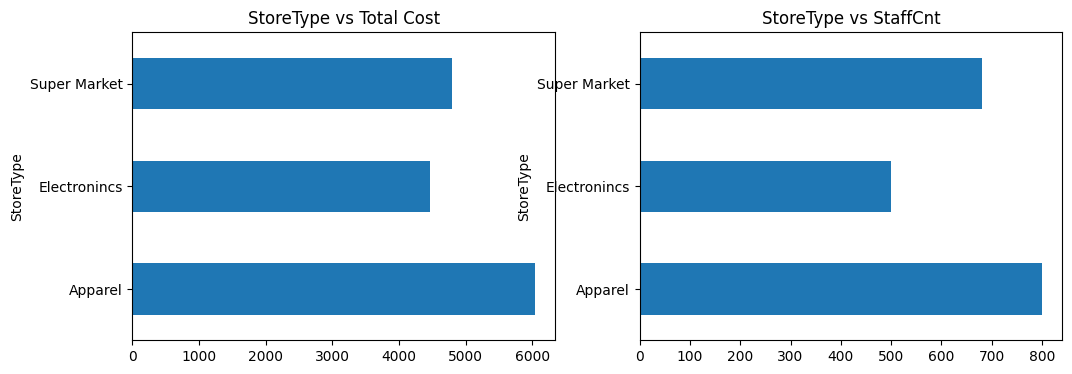

In [43]:
# Define the relationship between StoreType vs TotalCost & StoreType vs StaffCnt (as a SBS comparision) - bar chart
_, ax = plt.subplots(nrows=1, ncols=2, figsize =(12,4))

df.groupby('StoreType').TotalCost.sum().plot(kind = 'barh', ax=ax[0])
ax[0].set_title('StoreType vs Total Cost')
df.groupby('StoreType').StaffCnt.sum().plot(kind = 'barh', ax=ax[1])
ax[1].set_title('StoreType vs StaffCnt')
plt.show()

### Multivariate Charts


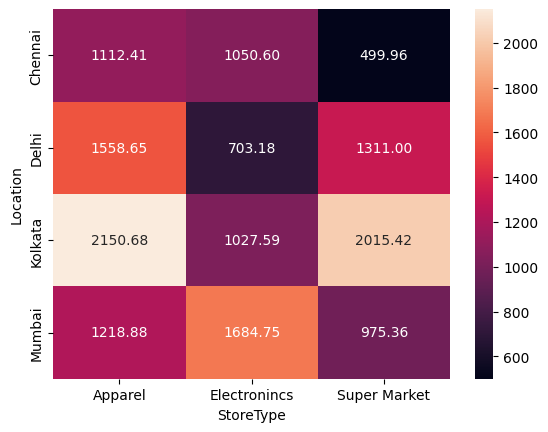

In [48]:
# Analyze the total cost by each location and Store Type
sns.heatmap(pd.pivot_table(data = df, index = 'Location', columns='StoreType', values='TotalCost', aggfunc='sum'), annot=True, fmt='.2f')
plt.show()

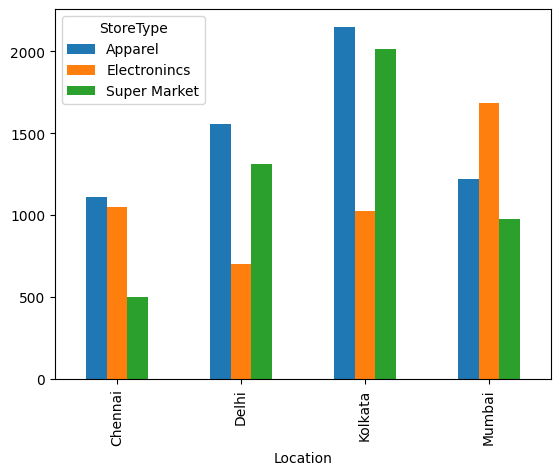

In [51]:
pd.pivot_table(data = df, index = 'Location', columns='StoreType', values='TotalCost', aggfunc='sum').plot(kind='bar')
plt.show()

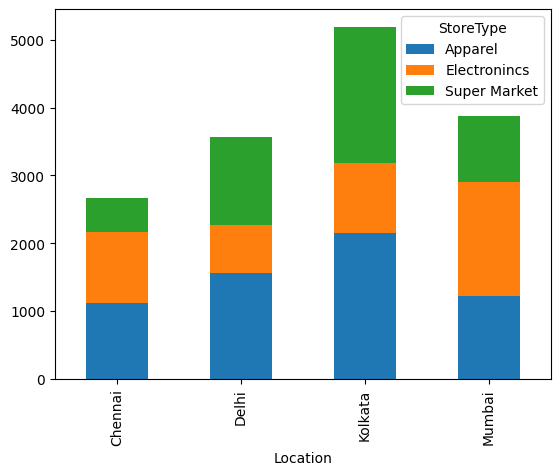

In [52]:
pd.pivot_table(data = df, index = 'Location', columns='StoreType', values='TotalCost', aggfunc='sum').plot(kind='bar', stacked=True)
plt.show()

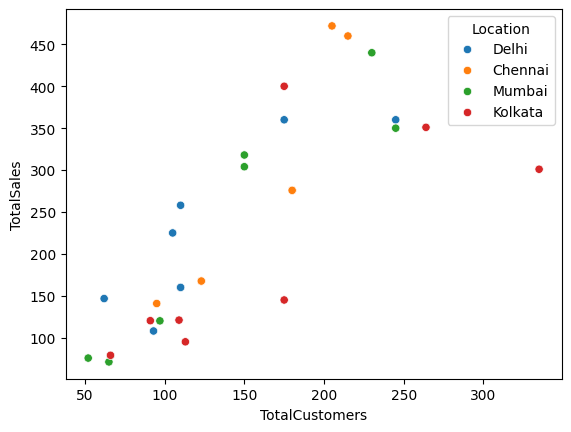

In [53]:
# Define relationship between TotalCustomer and TotalSales per location
sns.scatterplot(data = df, x = 'TotalCustomers', y = 'TotalSales', hue='Location')
plt.show()

In [ ]:
# Date time functionality

# Raw python - datetime - datetime/date/time
# pandas - Datetime64(series)/Timestamp (a single value)

from datetime import datetime

"""
Date time operations:
1. Fetching current date and time
2. Formatting string into datetime
3. Formatting a date time to define as a string.
4. Fetching date parts from date time
5. Creating date from date parts - Exploration
6. Date diff
7. Date add
"""

'\nDate time operations:\n1. Fetching current date and time\n2. Formatting string into datetime\n3. Formatting a date time to define as a string.\n4. Fetching date parts from date time\n5. Creating date from date parts\n6. Date diff\n7. Date add\n'

In [58]:
# 1. Fetching current date and time

datetime.now()

datetime.datetime(2025, 12, 7, 21, 43, 46, 184055)

In [59]:
datetime.today()

datetime.datetime(2025, 12, 7, 21, 44, 19, 637340)

In [60]:
pd.Timestamp.now()

Timestamp('2025-12-07 21:44:45.177647')

In [62]:
pd.Timestamp.today()

Timestamp('2025-12-07 21:45:01.041335')

In [ ]:
str1 = '101222'
datetime.strptime(str1, '%m%d%y')

datetime.datetime(2022, 10, 12, 0, 0)

In [70]:
s1 = pd.Series(['101222', '060512', '240624'])
pd.to_datetime(s1, format = '%d%m%y')

0   2022-12-10
1   2012-05-06
2   2024-06-24
dtype: datetime64[ns]

In [71]:
s2 = pd.Series(['12594011302020am', '09334010312009pm', '01045902282000am'])

pd.to_datetime(s2, format='%I%M%S%m%d%Y%p')

0   2020-11-30 00:59:40
1   2009-10-31 21:33:40
2   2000-02-28 01:04:59
dtype: datetime64[ns]

In [79]:
# 3. Formatting a date time to define as a string.
# .strftime - format time to string
datetime.strptime(str1, '%m%d%y').strftime('%A %d, %b %Y')

'Wednesday 12, Oct 2022'

In [82]:
# Take your birth date as input and format it - Abbreviated_month day, Year with century

#input() -> 12.07.2025

dob = input('Enter you DOB!')

In [84]:
datetime.strptime(dob, '%d/%m/%Y').strftime('%b %d, %Y')

'Dec 07, 2025'

In [86]:
# Format the series into Weekday day, Month Year
pd.to_datetime(s2, format='%I%M%S%m%d%Y%p').apply(lambda x: x.strftime('%A %d, %B %Y'))

0     Monday 30, November 2020
1    Saturday 31, October 2009
2     Monday 28, February 2000
dtype: object

In [87]:
pd.to_datetime(s2, format='%I%M%S%m%d%Y%p').dt.strftime('%A %d, %B %Y')

0     Monday 30, November 2020
1    Saturday 31, October 2009
2     Monday 28, February 2000
dtype: object

In [94]:
# 4. Fetching date parts from date time
pd.to_datetime(s2, format='%I%M%S%m%d%Y%p').dt.month_name()

0    November
1     October
2    February
dtype: object

In [ ]:
# Age, YoE - Date diff -> Timedelta
dob = '07/07/2020'
(pd.Timestamp.now() - pd.to_datetime(dob, format = '%d/%m/%Y')).days / 365.25

5.418206707734429

In [115]:
# Date add - Date of expiry
# Change the dob to year 1992 and 6th day of 6th month - 1992/06/06
pd.to_datetime(dob, format = '%d/%m/%Y') + pd.DateOffset(year = 1992, days=-1, months=-1)

Timestamp('1992-06-06 00:00:00')